# 📊 **ANALISIS RETANBILDAD DE CRIPTOMONEDAS EN 2025**

**Autor:** Raúl Marcos Sánchez 

**Fecha:** 8 Mayo 2026

---

In [1]:
import pandas as pd
import numpy as np
#from sklearn.preprocessing import MinMaxScaler
from datetime import datetime

Cargamos los datos de metadata y los analizamos

In [2]:
df = pd.read_csv("../DATA/top_500_metadata.csv")
df.head()

,id,symbol,name,image,current_price,market_cap,market_cap_rank,fully_diluted_valuation,total_volume,high_24h,...,total_supply,max_supply,ath,ath_change_percentage,ath_date,atl,atl_change_percentage,atl_date,roi,last_updated
0,bitcoin,btc,Bitcoin,https://coin-images.coingecko.com/coins/images...,90034.0,1796670281875,1,1796670281875,3.439365e+10,91673.0,...,1.995901e+07,2.100000e+07,126080.0,-28.76949,2025-10-06T18:57:42.558Z,67.81,1.323416e+05,2013-07-06T00:00:00.000Z,NaN,2025-12-07T23:33:52.059Z
1,ethereum,eth,Ethereum,https://coin-images.coingecko.com/coins/images...,3047.62,367795025205,2,367795025205,2.098058e+10,3145.89,...,1.206954e+08,NaN,4946.05,-38.61498,2025-08-24T19:21:03.333Z,0.432979,7.011197e+05,2015-10-20T00:00:00.000Z,"{'times': 44.269447818807166, 'currency': 'btc...",2025-12-07T23:33:44.339Z
2,tether,usdt,Tether,https://coin-images.coingecko.com/coins/images...,1.0,185668585289,3,191151709402,6.051337e+10,1.0,...,1.911141e+11,NaN,1.32,-24.40307,2018-07-24T00:00:00.000Z,0.572521,7.470440e+01,2015-03-02T00:00:00.000Z,NaN,2025-12-07T23:33:51.038Z
3,ripple,xrp,XRP,https://coin-images.coingecko.com/coins/images...,2.04,122855830675,4,203605167599,2.795817e+09,2.11,...,9.998575e+10,1.000000e+11,3.65,-44.26337,2025-07-18T03:40:53.808Z,0.00268621,7.555941e+04,2014-05-22T00:00:00.000Z,NaN,2025-12-07T23:33:49.957Z
4,binancecoin,bnb,BNB,https://coin-images.coingecko.com/coins/images...,892.15,122843693665,5,122843693665,1.401530e+09,905.07,...,1.377359e+08,2.000000e+08,1369.99,-35.04920,2025-10-13T08:41:24.131Z,0.0398177,2.234636e+06,2017-10-19T00:00:00.000Z,NaN,2025-12-07T23:33:51.812Z


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 26 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                500 non-null    str    
 1   symbol                            500 non-null    str    
 2   name                              500 non-null    str    
 3   image                             500 non-null    str    
 4   current_price                     500 non-null    str    
 5   market_cap                        500 non-null    int64  
 6   market_cap_rank                   500 non-null    int64  
 7   fully_diluted_valuation           500 non-null    int64  
 8   total_volume                      500 non-null    float64
 9   high_24h                          494 non-null    str    
 10  low_24h                           494 non-null    str    
 11  price_change_24h                  494 non-null    str    
 12  price_change_percen

In [4]:
df.columns

Index(['id', 'symbol', 'name', 'image', 'current_price', 'market_cap',
       'market_cap_rank', 'fully_diluted_valuation', 'total_volume',
       'high_24h', 'low_24h', 'price_change_24h',
       'price_change_percentage_24h', 'market_cap_change_24h',
       'market_cap_change_percentage_24h', 'circulating_supply',
       'total_supply', 'max_supply', 'ath', 'ath_change_percentage',
       'ath_date', 'atl', 'atl_change_percentage', 'atl_date', 'roi',
       'last_updated'],
      dtype='str')

In [5]:
# Extraemos de la tabla original las columnas que nos sirven para la resolucion del ejercicio
metadata = df[["symbol","market_cap", "total_volume","ath","current_price","high_24h","low_24h" ]]
metadata

,symbol,market_cap,total_volume,ath,current_price,high_24h,low_24h
0,btc,1796670281875,3.439365e+10,126080.0,90034.0,91673.0,87887.0
1,eth,367795025205,2.098058e+10,4946.05,3047.62,3145.89,2941.77
2,usdt,185668585289,6.051337e+10,1.32,1.0,1.0,1.0
3,xrp,122855830675,2.795817e+09,3.65,2.04,2.11,2.0
4,bnb,122843693665,1.401530e+09,1369.99,892.15,905.07,871.83
...,...,...,...,...,...,...,...
495,bc,77362507,1.798137e+04,0.01100698,0.00775978,0.00807202,0.00761125
496,vrsc,77313716,4.921460e+03,6.74,0.970701,0.980527,0.945662
497,vkhype,77308785,7.712420e+05,51.63,29.68,31.61,28.59
498,cfg,76741291,1.007799e+06,0.400363,0.133882,0.13742,0.127505


In [6]:
metadata.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   symbol         500 non-null    str    
 1   market_cap     500 non-null    int64  
 2   total_volume   500 non-null    float64
 3   ath            500 non-null    str    
 4   current_price  500 non-null    str    
 5   high_24h       494 non-null    str    
 6   low_24h        494 non-null    str    
dtypes: float64(1), int64(1), str(5)
memory usage: 27.5 KB


piloto_1

Limpieza basica de los datos que contienen las columnas con las que vamos a trabajar.

Convertimos columnas las columnas str a columnas numericas

In [7]:
cols_numeric = ["market_cap", "total_volume","ath","current_price","high_24h","low_24h"]
for col in cols_numeric:
    metadata[col] = pd.to_numeric(metadata[col], errors="coerce")

# Eliminar filas con datos faltantes en métricas clave
metadata = metadata.dropna(subset=cols_numeric)

# Cálculamos las métricas necesarias.

Volatilidad 24H

In [8]:
#volatilidad 24H
metadata["volatility_24h"] = (metadata["high_24h"] - metadata["low_24h"]) / metadata["current_price"]

Distancia al ATH

In [9]:
#distancia al ATH
metadata["ath_distance"] = (metadata["ath"] - metadata["current_price"]) / metadata["ath"]

In [10]:
metadata

,symbol,market_cap,total_volume,ath,current_price,high_24h,low_24h,volatility_24h,ath_distance
0,btc,1796670281875,3.439365e+10,126080.000000,90034.000000,91673.000000,87887.000000,0.042051,0.285898
1,eth,367795025205,2.098058e+10,4946.050000,3047.620000,3145.890000,2941.770000,0.066977,0.383827
2,usdt,185668585289,6.051337e+10,1.320000,1.000000,1.000000,1.000000,0.000000,0.242424
3,xrp,122855830675,2.795817e+09,3.650000,2.040000,2.110000,2.000000,0.053922,0.441096
4,bnb,122843693665,1.401530e+09,1369.990000,892.150000,905.070000,871.830000,0.037258,0.348791
...,...,...,...,...,...,...,...,...,...
495,bc,77362507,1.798137e+04,0.011007,0.007760,0.008072,0.007611,0.059379,0.295013
496,vrsc,77313716,4.921460e+03,6.740000,0.970701,0.980527,0.945662,0.035917,0.855979
497,vkhype,77308785,7.712420e+05,51.630000,29.680000,31.610000,28.590000,0.101752,0.425140
498,cfg,76741291,1.007799e+06,0.400363,0.133882,0.137420,0.127505,0.074058,0.665598


In [11]:
metadata.columns

Index(['symbol', 'market_cap', 'total_volume', 'ath', 'current_price',
       'high_24h', 'low_24h', 'volatility_24h', 'ath_distance'],
      dtype='str')

# Ranking Multicriterio:

El objetivo del ranking es seleccionar los 5 criptoactivos más relevantes del mercado, no los más rentables, sino los más sólidos, líquidos y representativos.
Por eso los pesos se asignan según la importancia real de cada métrica en el mercado cripto.

Porque prioriza lo que realmente define a un criptoactivo “importante”:

Tamaño del mercado

Liquidez

Riesgo razonable

Potencial de recuperación

Es un ranking equilibrado, defendible y alineado con metodologías de análisis financiero.

🏆 5. Ranking multicriterio. Ponderamos los datos en funcion de su importancia para el analisis a realizar.


Market Cap → 40%

Total Volumen → 30%

Volatility_24h → 20%

ATH_distance → 10%

In [12]:
metadata["ranking"] = (0.40 * metadata["market_cap"] + 0.30 * metadata["total_volume"] + 0.20 * metadata["volatility_24h"] + 0.10 * metadata["ath_distance"])

🥇 6. Selección de los 5 criptoactivos más importantes

In [13]:
top5 = metadata.sort_values("ranking", ascending=False).head(5)
top5_assets = top5["symbol"].tolist()

print("Los 5 criptoactivos seleccionados son:")
print(top5_assets)

top5_assets
top5

Los 5 criptoactivos seleccionados son:
['btc', 'eth', 'usdt', 'xrp', 'bnb']


,symbol,market_cap,total_volume,ath,current_price,high_24h,low_24h,volatility_24h,ath_distance,ranking
0,btc,1796670281875,3.439365e+10,126080.00,90034.00,91673.00,87887.00,0.042051,0.285898,7.289862e+11
1,eth,367795025205,2.098058e+10,4946.05,3047.62,3145.89,2941.77,0.066977,0.383827,1.534122e+11
2,usdt,185668585289,6.051337e+10,1.32,1.00,1.00,1.00,0.000000,0.242424,9.242145e+10
3,xrp,122855830675,2.795817e+09,3.65,2.04,2.11,2.00,0.053922,0.441096,4.998108e+10
4,bnb,122843693665,1.401530e+09,1369.99,892.15,905.07,871.83,0.037258,0.348791,4.955794e+10


graficas de seleccion de los 5 criptoactivos mas relevantes

In [14]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

plt.style.use("seaborn-v0_8")
sns.set_palette("tab10")

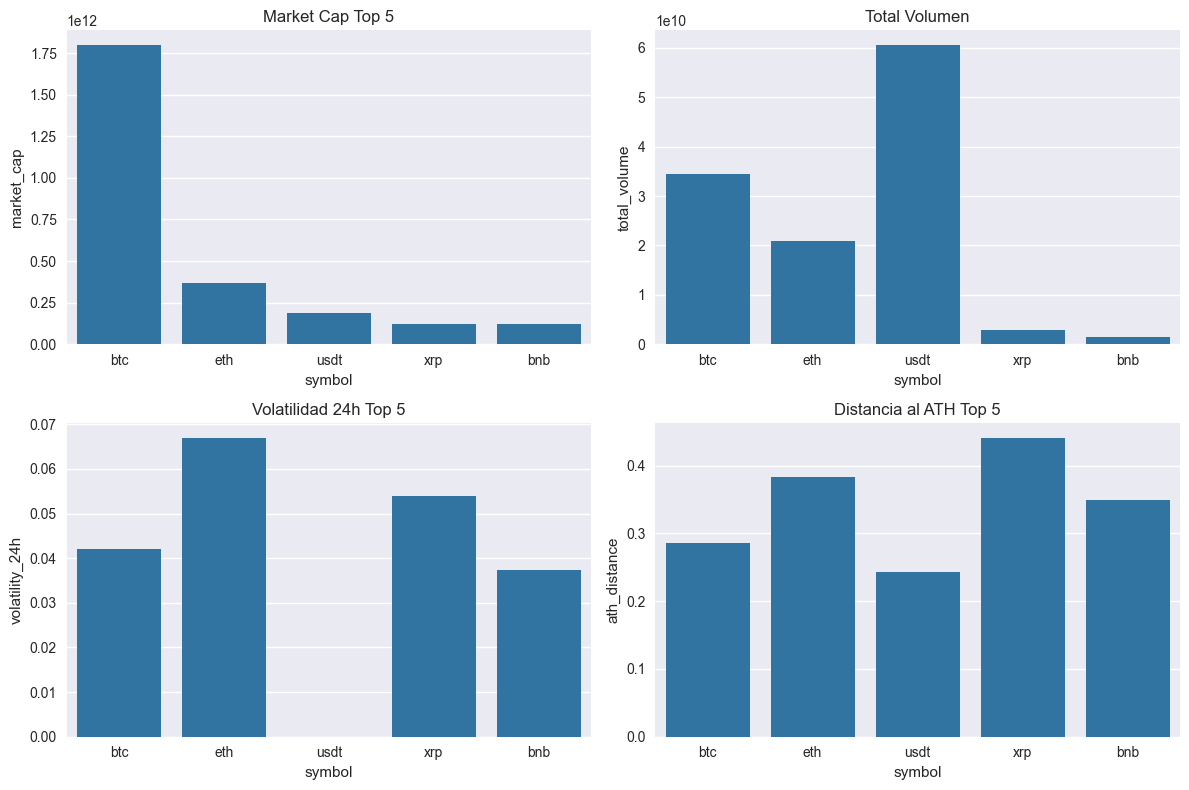

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

sns.barplot(data=top5, x="symbol", y="market_cap", ax=axes[0])
axes[0].set_title("Market Cap Top 5")

sns.barplot(data=top5, x="symbol", y="total_volume", ax=axes[1])
axes[1].set_title("Total Volumen")

sns.barplot(data=top5, x="symbol", y="volatility_24h", ax=axes[2])
axes[2].set_title("Volatilidad 24h Top 5")

sns.barplot(data=top5, x="symbol", y="ath_distance", ax=axes[3])
axes[3].set_title("Distancia al ATH Top 5")

plt.tight_layout()
plt.show()

📈 7. Preparar datos OHLC para el PASO 2

In [16]:
ohlc = pd.read_csv("../DATA/crypto_ohlc.csv")
ohlc.head()

,coin_id,symbol,timestamp,date,open,high,low,close
0,bitcoin,btc,1733529600000,2024-12-07,97072.0,102034.0,96589.0,99974.0
1,bitcoin,btc,1733875200000,2024-12-11,99928.0,101235.0,94387.0,96650.0
2,bitcoin,btc,1734220800000,2024-12-15,96643.0,102658.0,95741.0,101367.0
3,bitcoin,btc,1734566400000,2024-12-19,101393.0,108135.0,100237.0,100356.0
4,bitcoin,btc,1734912000000,2024-12-23,100139.0,102759.0,92245.0,95094.0


In [17]:
ohlc.info()

<class 'pandas.DataFrame'>
RangeIndex: 39235 entries, 0 to 39234
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   coin_id    39235 non-null  str  
 1   symbol     39235 non-null  str  
 2   timestamp  39235 non-null  int64
 3   date       39235 non-null  str  
 4   open       39235 non-null  str  
 5   high       39235 non-null  str  
 6   low        39235 non-null  str  
 7   close      39235 non-null  str  
dtypes: int64(1), str(7)
memory usage: 2.4 MB


In [18]:
cols_numeric = ["open", "high","low","close"]
for col in cols_numeric:
    ohlc[col] = pd.to_numeric(ohlc[col], errors="coerce")

# Eliminar filas con datos faltantes en métricas clave
ohlc = ohlc.dropna(subset=cols_numeric)

In [19]:
ohlc.info()

<class 'pandas.DataFrame'>
Index: 38625 entries, 0 to 39234
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   coin_id    38625 non-null  str    
 1   symbol     38625 non-null  str    
 2   timestamp  38625 non-null  int64  
 3   date       38625 non-null  str    
 4   open       38625 non-null  float64
 5   high       38625 non-null  float64
 6   low        38625 non-null  float64
 7   close      38625 non-null  float64
dtypes: float64(4), int64(1), str(3)
memory usage: 2.7 MB


Transformar la columna fecha

In [20]:
ohlc.columns

Index(['coin_id', 'symbol', 'timestamp', 'date', 'open', 'high', 'low',
       'close'],
      dtype='str')

In [21]:
# Filtrar solo los 5 activos seleccionados
ohlc_top5 = ohlc[ohlc["symbol"].isin(top5_assets)]
ohlc_top5

,coin_id,symbol,timestamp,date,open,high,low,close
0,bitcoin,btc,1733529600000,2024-12-07,97072.000000,102034.0,96589.000000,99974.000000
1,bitcoin,btc,1733875200000,2024-12-11,99928.000000,101235.0,94387.000000,96650.000000
2,bitcoin,btc,1734220800000,2024-12-15,96643.000000,102658.0,95741.000000,101367.000000
3,bitcoin,btc,1734566400000,2024-12-19,101393.000000,108135.0,100237.000000,100356.000000
4,bitcoin,btc,1734912000000,2024-12-23,100139.000000,102759.0,92245.000000,95094.000000
...,...,...,...,...,...,...,...,...
36924,cronos-bridged-usdt-cronos,usdt,1763596800000,2025-11-20,1001.000000,1009.0,0.989211,1.000000
36925,cronos-bridged-usdt-cronos,usdt,1763942400000,2025-11-24,1.000000,1008.0,0.992097,0.998818
36926,cronos-bridged-usdt-cronos,usdt,1764288000000,2025-11-28,0.999405,1006.0,0.994320,0.998501
36927,cronos-bridged-usdt-cronos,usdt,1764633600000,2025-12-02,0.998805,1006.0,0.986816,0.997944


In [22]:
ohlc_top5.columns

Index(['coin_id', 'symbol', 'timestamp', 'date', 'open', 'high', 'low',
       'close'],
      dtype='str')

In [23]:
ohlc_top5 = ohlc_top5.drop(columns = ["coin_id"])

In [24]:
ohlc_top5

,symbol,timestamp,date,open,high,low,close
0,btc,1733529600000,2024-12-07,97072.000000,102034.0,96589.000000,99974.000000
1,btc,1733875200000,2024-12-11,99928.000000,101235.0,94387.000000,96650.000000
2,btc,1734220800000,2024-12-15,96643.000000,102658.0,95741.000000,101367.000000
3,btc,1734566400000,2024-12-19,101393.000000,108135.0,100237.000000,100356.000000
4,btc,1734912000000,2024-12-23,100139.000000,102759.0,92245.000000,95094.000000
...,...,...,...,...,...,...,...
36924,usdt,1763596800000,2025-11-20,1001.000000,1009.0,0.989211,1.000000
36925,usdt,1763942400000,2025-11-24,1.000000,1008.0,0.992097,0.998818
36926,usdt,1764288000000,2025-11-28,0.999405,1006.0,0.994320,0.998501
36927,usdt,1764633600000,2025-12-02,0.998805,1006.0,0.986816,0.997944


Transformamos la columna fecha a tipo de caracter date

In [25]:
from datetime import datetime
# Convertir timestamp
#ohlc_top5['timestamp'] = ohlc_top5['timestamp'].astype(float)
ohlc_top5['date'] = pd.to_datetime(ohlc_top5['timestamp'], unit='ms')

In [26]:
ohlc_top5.info()

<class 'pandas.DataFrame'>
Index: 644 entries, 0 to 36928
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   symbol     644 non-null    str           
 1   timestamp  644 non-null    int64         
 2   date       644 non-null    datetime64[ms]
 3   open       644 non-null    float64       
 4   high       644 non-null    float64       
 5   low        644 non-null    float64       
 6   close      644 non-null    float64       
dtypes: datetime64[ms](1), float64(4), int64(1), str(1)
memory usage: 40.2 KB


🧪 8. Cálculo de rentabilidad 2025 (para hipótesis)

In [27]:
# Filtrar año 2025
ohlc_2025 = ohlc_top5[
    (ohlc_top5["date"] >= "2025-01-01") &
    (ohlc_top5["date"] <= "2025-12-31")
]

# Rentabilidad anual por activo
returns_2025 = (
    ohlc_2025.groupby("symbol")
    .apply(lambda df: (df["close"].iloc[-1] - df["close"].iloc[0]) / df["close"].iloc[0])
    .reset_index(name="annual_return")
)

returns_2025

,symbol,annual_return
0,bnb,0.239282
1,btc,-0.089485
2,eth,-0.161372
3,usdt,0.000085
4,xrp,-0.167347


---

piloto_2

# 🚀 PASO 2 — EDA Completo para los 5 Criptoactivos Seleccionados

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
# Asegurar formato de fecha
ohlc_top5["date"] = pd.to_datetime(ohlc_top5["date"])

# Ordenar por fecha
ohlc_top5 = ohlc_top5.sort_values(["symbol", "date"])
ohlc_top5

,symbol,timestamp,date,open,high,low,close
368,bnb,1733529600000,2024-12-07,719.14,748.28,709.47,732.54
369,bnb,1733875200000,2024-12-11,731.84,760.89,651.60,675.42
370,bnb,1734220800000,2024-12-15,675.88,732.40,659.76,715.45
371,bnb,1734566400000,2024-12-19,715.52,735.66,686.72,687.66
372,bnb,1734912000000,2024-12-23,685.72,704.59,618.83,648.57
...,...,...,...,...,...,...,...
363,xrp,1763596800000,2025-11-20,2.23,2.28,2.03,2.11
364,xrp,1763942400000,2025-11-24,2.11,2.14,1.83,2.04
365,xrp,1764288000000,2025-11-28,2.05,2.28,2.03,2.20
366,xrp,1764633600000,2025-12-02,2.20,2.26,1.99,2.03


📈 2. Rentabilidad diaria

In [30]:
ohlc_top5["daily_return"] = ohlc_top5.groupby("symbol")["close"].pct_change()
ohlc_top5

,symbol,timestamp,date,open,high,low,close,daily_return
368,bnb,1733529600000,2024-12-07,719.14,748.28,709.47,732.54,NaN
369,bnb,1733875200000,2024-12-11,731.84,760.89,651.60,675.42,-0.077975
370,bnb,1734220800000,2024-12-15,675.88,732.40,659.76,715.45,0.059267
371,bnb,1734566400000,2024-12-19,715.52,735.66,686.72,687.66,-0.038843
372,bnb,1734912000000,2024-12-23,685.72,704.59,618.83,648.57,-0.056845
...,...,...,...,...,...,...,...,...
363,xrp,1763596800000,2025-11-20,2.23,2.28,2.03,2.11,-0.058036
364,xrp,1763942400000,2025-11-24,2.11,2.14,1.83,2.04,-0.033175
365,xrp,1764288000000,2025-11-28,2.05,2.28,2.03,2.20,0.078431
366,xrp,1764633600000,2025-12-02,2.20,2.26,1.99,2.03,-0.077273


In [31]:
# Eliminar filas con datos faltantes en daily_return
ohlc_top5 = ohlc_top5.dropna(subset=['daily_return'])
ohlc_top5

,symbol,timestamp,date,open,high,low,close,daily_return
369,bnb,1733875200000,2024-12-11,731.84,760.89,651.60,675.42,-0.077975
370,bnb,1734220800000,2024-12-15,675.88,732.40,659.76,715.45,0.059267
371,bnb,1734566400000,2024-12-19,715.52,735.66,686.72,687.66,-0.038843
372,bnb,1734912000000,2024-12-23,685.72,704.59,618.83,648.57,-0.056845
373,bnb,1735257600000,2024-12-27,648.82,716.37,638.46,687.52,0.060055
...,...,...,...,...,...,...,...,...
363,xrp,1763596800000,2025-11-20,2.23,2.28,2.03,2.11,-0.058036
364,xrp,1763942400000,2025-11-24,2.11,2.14,1.83,2.04,-0.033175
365,xrp,1764288000000,2025-11-28,2.05,2.28,2.03,2.20,0.078431
366,xrp,1764633600000,2025-12-02,2.20,2.26,1.99,2.03,-0.077273


creamos una tabla alternativa sin el activo usdt

In [72]:
ohlc_top5_R = ohlc_top5[ohlc_top5["symbol"] != "usdt"]
ohlc_top5_R["symbol"].unique()


<StringArray>
['bnb', 'btc', 'eth', 'xrp']
Length: 4, dtype: str

Boxplot de retornos diario

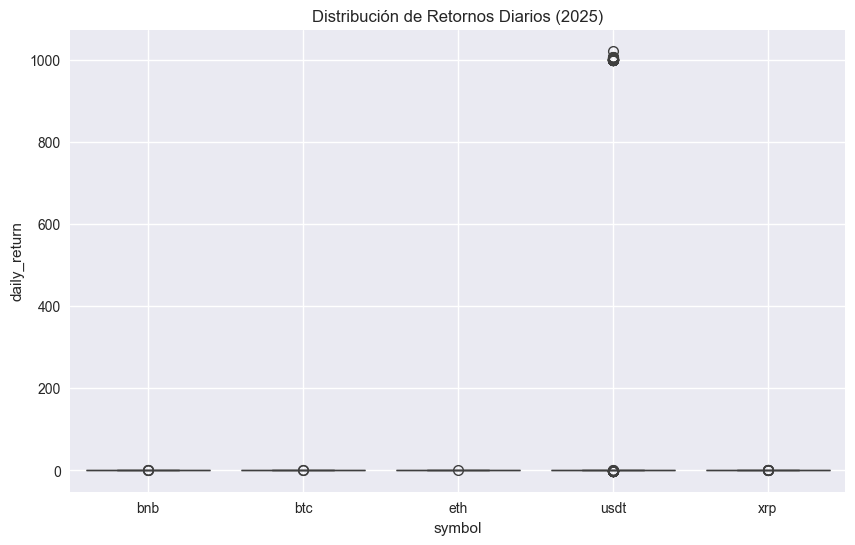

In [71]:
plt.figure(figsize=(10,6))
sns.boxplot(data=ohlc_top5, x="symbol", y="daily_return")
plt.title("Distribución de Retornos Diarios (2025)")
plt.grid(True)
plt.show()

elimino USDT

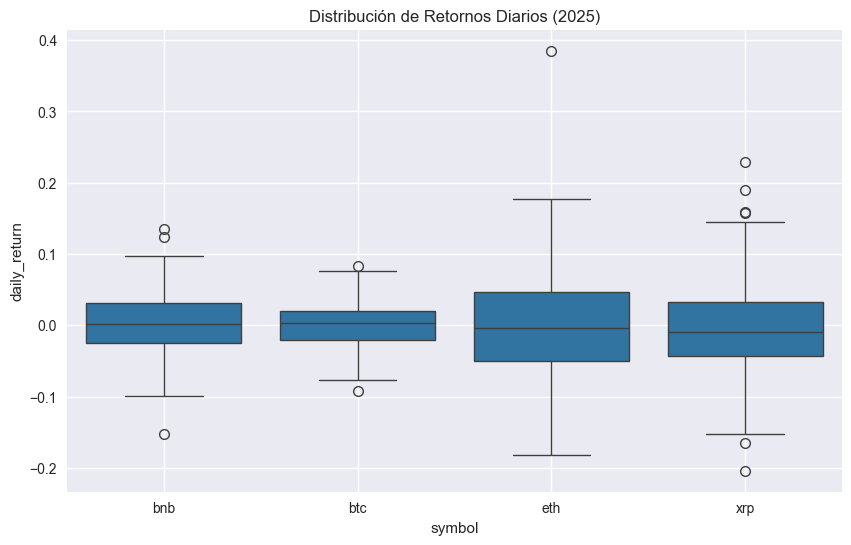

In [73]:
plt.figure(figsize=(10,6))
sns.boxplot(data=ohlc_top5_R, x="symbol", y="daily_return")
plt.title("Distribución de Retornos Diarios (2025)")
plt.grid(True)
plt.show()

📉 3. Volatilidad diaria

In [82]:
df_volatility = (
    ohlc_top5.groupby("symbol")["daily_return"]
    .std()
    .reset_index(name="daily_volatility")
)

df_volatility


,symbol,daily_volatility
0,bnb,0.049059
1,btc,0.035361
2,eth,0.079837
3,usdt,399.597477
4,xrp,0.073871


Gráfico circular profesional (donut chart) de volatilidad diaria sin USDT

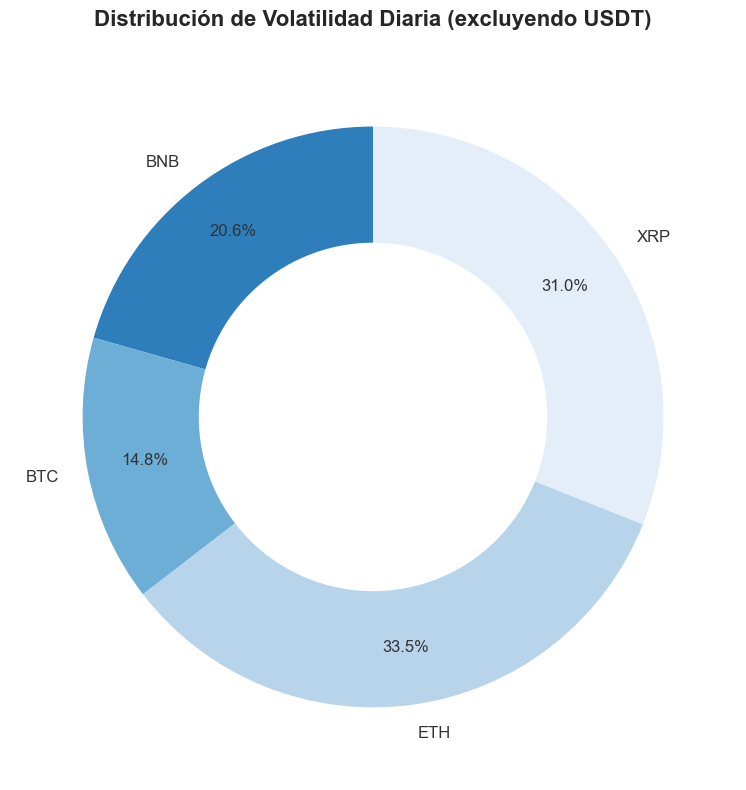

In [92]:
import matplotlib.pyplot as plt

# Filtrar USDT
df_vol_no_usdt = df_volatility[df_volatility["symbol"] != "usdt"]

# Colores profesionales (azules suaves)
colors = plt.cm.Blues_r(np.linspace(0.3, 0.9, len(df_vol_no_usdt)))

# Crear figura
fig, ax = plt.subplots(figsize=(8, 8))

# Pie chart
wedges, texts, autotexts = ax.pie(
    df_vol_no_usdt["daily_volatility"],
    labels=df_vol_no_usdt["symbol"].str.upper(),
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    pctdistance=0.8,
    textprops={"fontsize": 12, "color": "#333"}
)

# Donut: círculo blanco interior
centre_circle = plt.Circle((0, 0), 0.60, fc="white")
fig.gca().add_artist(centre_circle)

# Título elegante
plt.title(
    "Distribución de Volatilidad Diaria (excluyendo USDT)",
    fontsize=16,
    fontweight="bold",
    pad=20
)

# Ajustes finales
plt.tight_layout()
plt.show()



📊 4. Rentabilidad acumulada en 2025

<Figure size 1200x600 with 0 Axes>

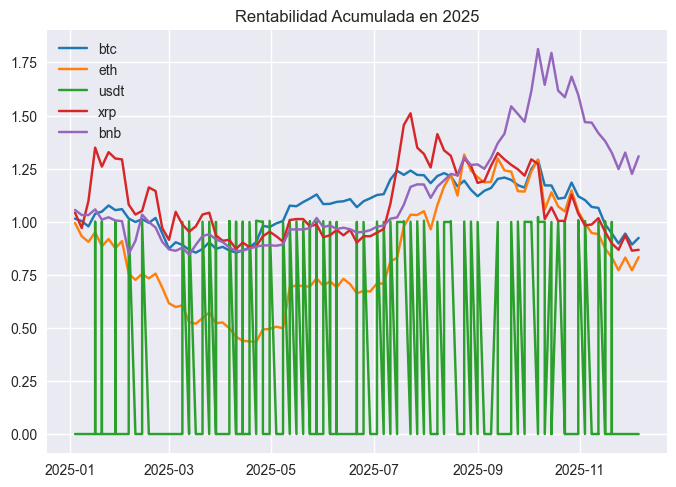

In [93]:
ohlc_2025 = ohlc_top5[(ohlc_top5["date"] >= "2025-01-01") & (ohlc_top5["date"] <= "2025-12-31")]

ohlc_2025["cum_return"] = (1 + ohlc_top5["daily_return"]).groupby(ohlc_top5["symbol"]).cumprod()


# Gráfico de rentabilidad acumulada
plt.figure(figsize=(12,6))
plt.figure()
for sym in top5_assets:
    df = ohlc_2025[ohlc_2025["symbol"] == sym]
    plt.plot(df["date"], df["cum_return"], label=sym)

plt.title("Rentabilidad Acumulada en 2025")
plt.legend()
plt.grid(True)
plt.show()


eliminamos de la selecion a USDT. raul 13.05.2026

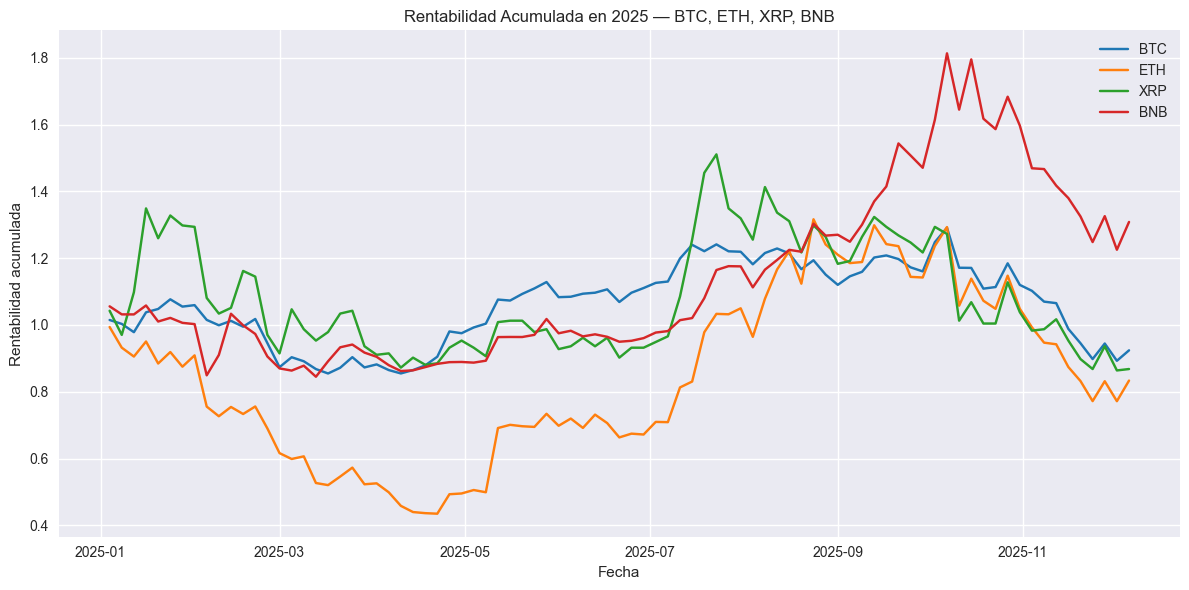

In [69]:

# Símbolos que quieres graficar
symbols = ["btc", "eth", "xrp", "bnb"]

# Gráfico de rentabilidad acumulada
plt.figure(figsize=(12,6))

for sym in symbols:
    df = ohlc_2025[ohlc_2025["symbol"] == sym]
    plt.plot(df["date"], df["cum_return"], label=sym.upper())

plt.title("Rentabilidad Acumulada en 2025 — BTC, ETH, XRP, BNB")
plt.xlabel("Fecha")
plt.ylabel("Rentabilidad acumulada")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


sacarlos en un recuadro de 4 graficos

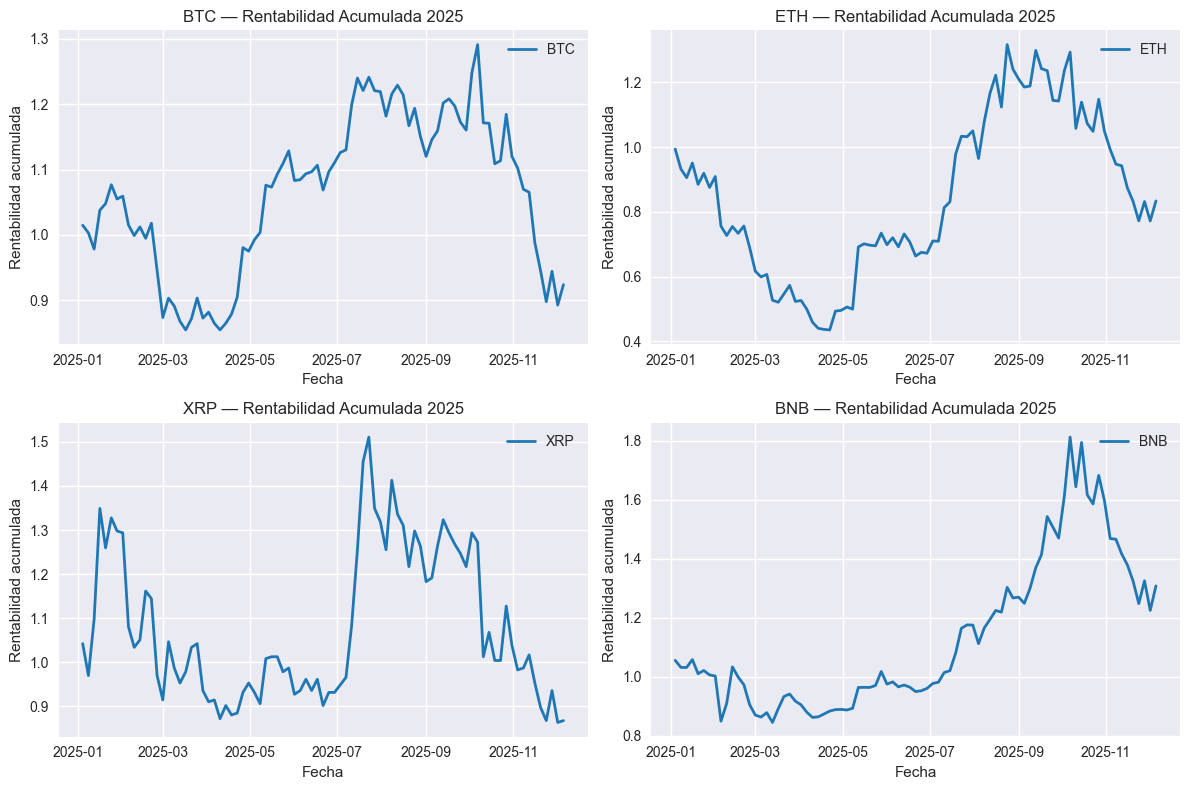

In [90]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

symbols = ["btc", "eth", "xrp", "bnb"]

for i, sym in enumerate(symbols):
    ax = axes[i]
    df = ohlc_2025[ohlc_2025["symbol"] == sym]

    ax.plot(df["date"], df["cum_return"], label=sym.upper(), linewidth=2)
    ax.set_title(f"{sym.upper()} — Rentabilidad Acumulada 2025")
    ax.set_xlabel("Fecha")
    ax.set_ylabel("Rentabilidad acumulada")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()




📉 5. Máximo Drawdown

In [78]:
def max_drawdown(series):
    cumulative = (1 + series).cumprod()
    peak = cumulative.cummax()
    drawdown = (cumulative - peak) / peak
    return drawdown.min()

drawdowns = (
    ohlc_2025.groupby("symbol")["daily_return"]
    .apply(max_drawdown)
    .reset_index(name="max_drawdown")
)

drawdowns

,symbol,max_drawdown
0,bnb,-0.324261
1,btc,-0.308502
2,eth,-0.562341
3,usdt,-0.999029
4,xrp,-0.428169


In [80]:
import pandas as pd

df_drawdown = pd.DataFrame({
    "symbol": ["bnb", "btc", "eth", "usdt", "xrp"],
    "max_drawdown": [-0.324261, -0.308502, -0.562341, -0.999029, -0.428169]
})

df_drawdown


,symbol,max_drawdown
0,bnb,-0.324261
1,btc,-0.308502
2,eth,-0.562341
3,usdt,-0.999029
4,xrp,-0.428169


C:\Users\data_\AppData\Local\Temp\ipykernel_1420\3924844210.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


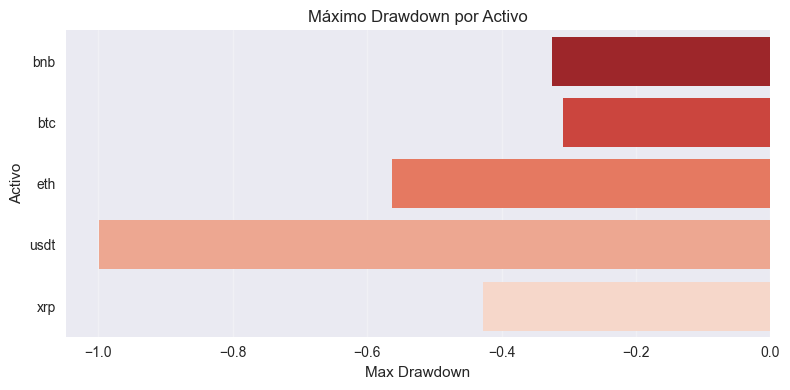

In [81]:
import seaborn as sns
import matplotlib.pyplot as plt

# Suponiendo que tu tabla está en un DataFrame llamado df_drawdown
# con columnas: symbol, max_drawdown

plt.figure(figsize=(8, 4))
sns.barplot(
    data=df_drawdown,
    x="max_drawdown",
    y="symbol",
    palette="Reds_r"  # Colores de más claro a más intenso
)

plt.title("Máximo Drawdown por Activo")
plt.xlabel("Max Drawdown")
plt.ylabel("Activo")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


📊 6. Sharpe Ratio (riesgo–retorno)
Asumimos tasa libre de riesgo = 0

In [37]:
sharpe = (
    ohlc_2025.groupby("symbol")["daily_return"]
    .apply(lambda x: x.mean() / x.std())
    .reset_index(name="sharpe_ratio")
)

sharpe

,symbol,sharpe_ratio
0,bnb,0.079116
1,btc,0.005387
2,eth,0.022557
3,usdt,0.504489
4,xrp,0.035242


7.Tabla resumen de los ratios calculados

In [38]:

summary = (
    returns_2025
    .merge(volatility, on="symbol")
    .merge(drawdowns, on="symbol")
    .merge(sharpe, on="symbol")
)

summary

,symbol,annual_return,daily_volatility,max_drawdown,sharpe_ratio
0,bnb,0.239282,0.049540,-0.324261,0.079116
1,btc,-0.089485,0.035334,-0.308502,0.005387
2,eth,-0.161372,0.080046,-0.562341,0.022557
3,usdt,0.000085,399.045131,-0.999029,0.504489
4,xrp,-0.167347,0.073527,-0.428169,0.035242


🔗 8. HEATMAP.Correlación entre los activos.

In [43]:
ohlc_top5.info()

<class 'pandas.DataFrame'>
Index: 639 entries, 369 to 367
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   symbol        639 non-null    str           
 1   timestamp     639 non-null    int64         
 2   date          639 non-null    datetime64[ms]
 3   open          639 non-null    float64       
 4   high          639 non-null    float64       
 5   low           639 non-null    float64       
 6   close         639 non-null    float64       
 7   daily_return  639 non-null    float64       
dtypes: datetime64[ms](1), float64(5), int64(1), str(1)
memory usage: 61.1 KB


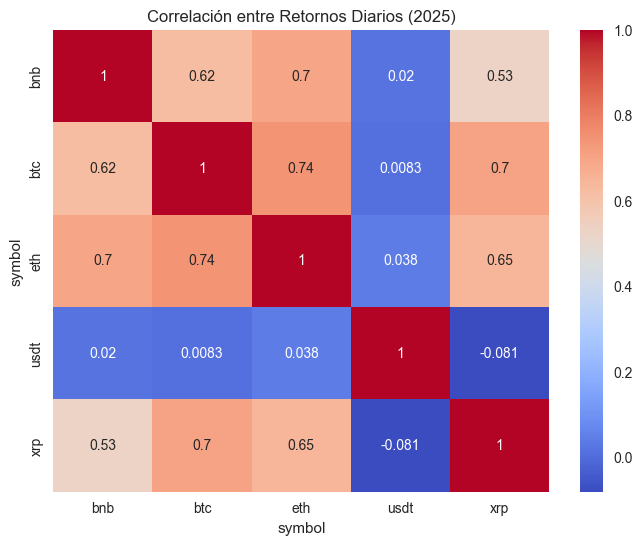

In [44]:
pivot_returns = ohlc_2025.pivot_table(index="date", columns="symbol", values="daily_return")

plt.figure(figsize=(8,6))
sns.heatmap(pivot_returns.corr(), annot=True, cmap="coolwarm")
plt.title("Correlación entre Retornos Diarios (2025)")
plt.show()


📈 9. Momentum (90 días)

In [45]:
ohlc_top5["momentum_90d"] = (
    ohlc_top5.groupby("symbol")["close"]
    .pct_change(periods=90)
)

Momentum 90 días y relación con rentabilidad

In [46]:
ohlc_top5 = ohlc_top5.sort_values(["symbol", "date"])
ohlc_top5["daily_return"] = (
    ohlc_top5.groupby("symbol")["close"].pct_change()
)

ohlc_top5["momentum_90d"] = (
    ohlc_top5.groupby("symbol")["close"].pct_change(periods=90)
)

momentum_2025 = (
    ohlc_top5[
        (ohlc_top5["date"] >= "2025-01-01") &
        (ohlc_top5["date"] <= "2025-12-31")
    ]
    .groupby("symbol")["momentum_90d"]
    .mean()
    .reset_index(name="momentum_90d_mean")
)

summary_mom = summary.merge(momentum_2025, on="symbol")
summary_mom

,symbol,annual_return,daily_volatility,max_drawdown,sharpe_ratio,momentum_90d_mean
0,bnb,0.239282,0.049540,-0.324261,0.079116,0.308327
1,btc,-0.089485,0.035334,-0.308502,0.005387,-0.075975
2,eth,-0.161372,0.080046,-0.562341,0.022557,-0.166528
3,usdt,0.000085,399.045131,-0.999029,0.504489,259.892281
4,xrp,-0.167347,0.073527,-0.428169,0.035242,-0.131915


Gráfico simple rentabilidad vs momentum

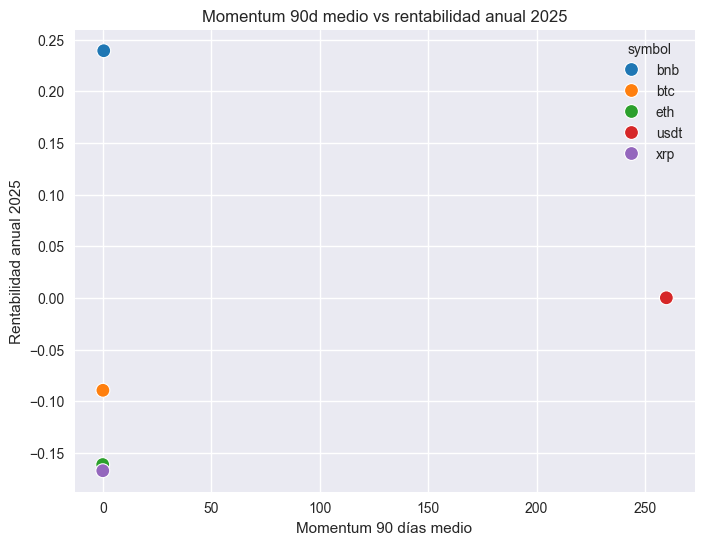

In [47]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=summary_mom,
    x="momentum_90d_mean",
    y="annual_return",
    hue="symbol",
    s=100
)
plt.title("Momentum 90d medio vs rentabilidad anual 2025")
plt.xlabel("Momentum 90 días medio")
plt.ylabel("Rentabilidad anual 2025")
plt.grid(True)
plt.show()

🧪 10. Tabla resumen para contrastar hipótesis

In [48]:
summary = (
    returns_2025
    .merge(volatility, on="symbol")
    .merge(drawdowns, on="symbol")
    .merge(sharpe, on="symbol")
)

summary

,symbol,annual_return,daily_volatility,max_drawdown,sharpe_ratio
0,bnb,0.239282,0.049540,-0.324261,0.079116
1,btc,-0.089485,0.035334,-0.308502,0.005387
2,eth,-0.161372,0.080046,-0.562341,0.022557
3,usdt,0.000085,399.045131,-0.999029,0.504489
4,xrp,-0.167347,0.073527,-0.428169,0.035242


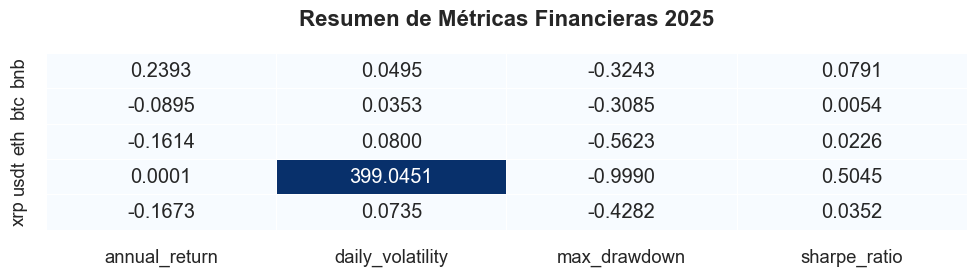

In [95]:
import seaborn as sns
import matplotlib.pyplot as plt

# Estilo profesional
sns.set_theme(style="whitegrid", font_scale=1.2)

plt.figure(figsize=(10, 3))

# Tabla como heatmap suave
sns.heatmap(
    summary.set_index("symbol"),
    annot=True,
    fmt=".4f",
    cmap="Blues",
    linewidths=0.5,
    cbar=False
)

plt.title("Resumen de Métricas Financieras 2025", fontsize=16, fontweight="bold", pad=20)
plt.xlabel("")
plt.ylabel("")

plt.tight_layout()
plt.show()


In [98]:
import os
os.getcwd()

fig.savefig('resumen_metricas_fiancieras')

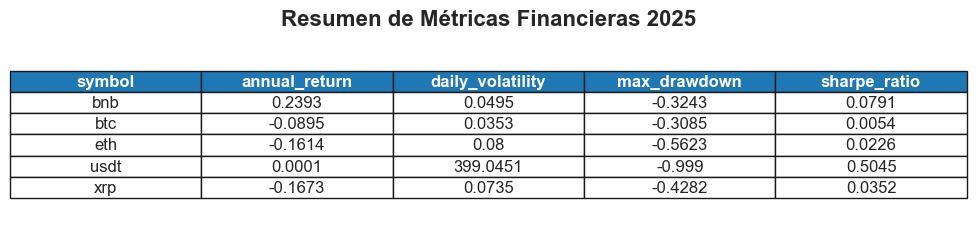

In [96]:
import pandas as pd
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 2.5))

# Ocultar ejes
ax.axis("off")

# Tabla formateada
tabla = ax.table(
    cellText=summary.round(4).values,
    colLabels=summary.columns,
    cellLoc="center",
    loc="center"
)

# Estilo profesional
tabla.auto_set_font_size(False)
tabla.set_fontsize(12)
tabla.scale(1, 1.5)

# Negrita en encabezados
for key, cell in tabla.get_celld().items():
    if key[0] == 0:
        cell.set_text_props(weight="bold")
        cell.set_facecolor("#1f77b4")
        cell.set_text_props(color="white")

plt.title("Resumen de Métricas Financieras 2025", fontsize=16, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()


HACER UN TABLA DE 4 MOSTRANDO LOS 4 ACTIVOS CON ESTOS RATIOS

🎯 Objetivos de estos ratios:


✔ Comparar rentabilidad anual

✔ Evaluar volatilidad

✔ Medir riesgo (drawdown)

✔ Comparar Sharpe Ratio

✔ Analizar momentum

✔ Ver correlaciones entre activos

✔ Visualizar comportamiento temporal

Todo esto te permite contrastar las hipótesis planteadas en el PASO 1.

---

pilo_3

📌 1. Preparación del dataset

📈 2. Cálculo de retornos diarios

📉 3. Volatilidad diaria por activo

📊 4. Rentabilidad acumulada en 2025

📉 5. Máximo Drawdown

📊 6. Sharpe Ratio

🔥 7. Distribución de retornos diarios (Boxplot)

🔗 8. Correlación entre activos

📈 9. Momentum de 90 días

📘 10. Tabla resumen para contrastar hipótesis

🧠 **Interpretación del EDA (estructura)

---

piloto_4

2.0. Codigo para contraste de hipotesis

2.1. ANOVA sobre rentabilidad anual (H1)

In [49]:
from scipy import stats

# Supone que returns_2025 tiene columnas: symbol, annual_return
groups = [returns_2025[returns_2025["symbol"] == sym]["annual_return"].values for sym in top5_assets]

f_stat, p_value = stats.f_oneway(*groups)
print("ANOVA rentabilidad anual - F:", f_stat, "p-value:", p_value)


ANOVA rentabilidad anual - F: nan p-value: nan


c:\Users\data_\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: SmallSampleWarning: all input arrays have length 1.  f_oneway requires that at least one input has length greater than 1.
  if is_too_small(samples, kwds):
C:\Users\data_\AppData\Local\Temp\ipykernel_1420\354183760.py:6: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p_value = stats.f_oneway(*groups)


2.2. Correlación volatilidad–rentabilidad (H2)

In [50]:
corr_v_r = summary["daily_volatility"].corr(summary["annual_return"])
print("Correlación volatilidad vs rentabilidad:", corr_v_r)


Correlación volatilidad vs rentabilidad: 0.11924002585148709


In [51]:
summary

,symbol,annual_return,daily_volatility,max_drawdown,sharpe_ratio
0,bnb,0.239282,0.049540,-0.324261,0.079116
1,btc,-0.089485,0.035334,-0.308502,0.005387
2,eth,-0.161372,0.080046,-0.562341,0.022557
3,usdt,0.000085,399.045131,-0.999029,0.504489
4,xrp,-0.167347,0.073527,-0.428169,0.035242


Con pocos activos, mejor interpretación descriptiva

Debemos descartar el criptoactivo usdt, ya que su valor siempre es 1 y no obtenemos rentabilidad.

max_drawdown = Cuanto más cercano a 0 MEJOR

sharpe_ratio = Cuanto más alto MEJOR

12. Gráficas resumen de métricas (para concluir fácil)

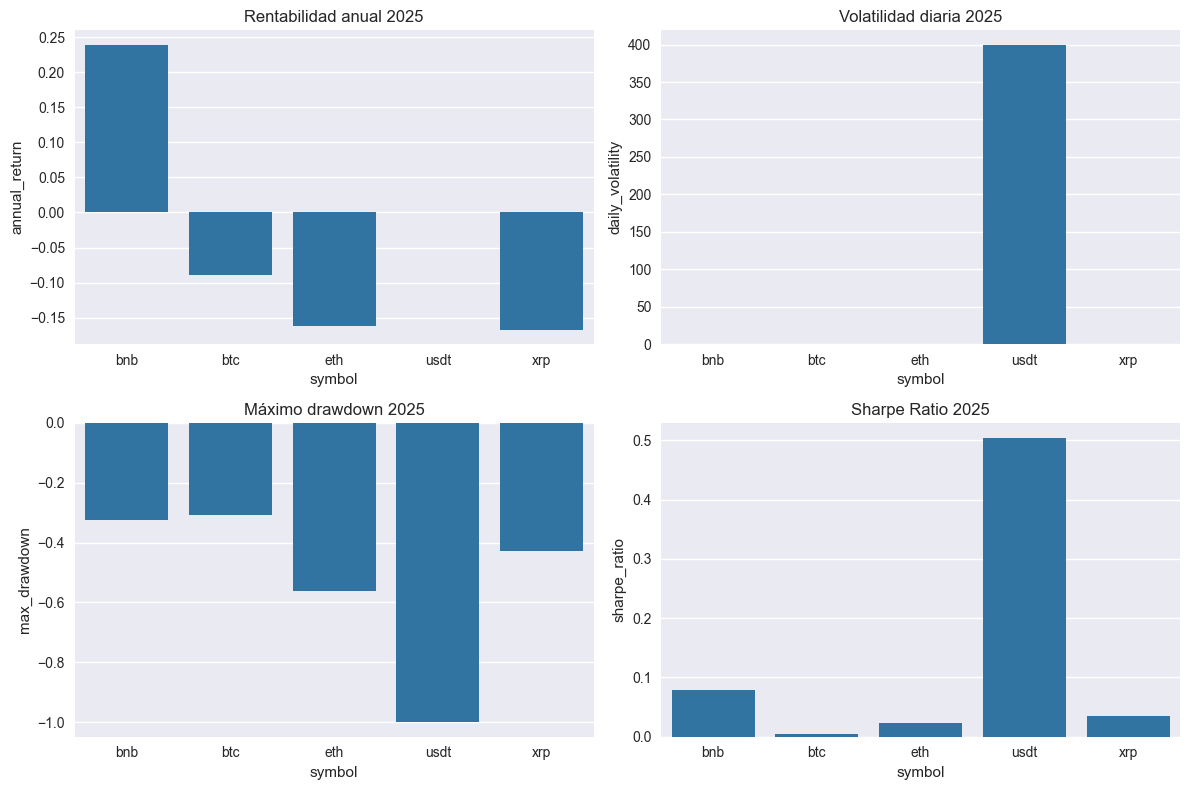

In [52]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

sns.barplot(data=summary, x="symbol", y="annual_return", ax=axes[0])
axes[0].set_title("Rentabilidad anual 2025")

sns.barplot(data=summary, x="symbol", y="daily_volatility", ax=axes[1])
axes[1].set_title("Volatilidad diaria 2025")

sns.barplot(data=summary, x="symbol", y="max_drawdown", ax=axes[2])
axes[2].set_title("Máximo drawdown 2025")

sns.barplot(data=summary, x="symbol", y="sharpe_ratio", ax=axes[3])
axes[3].set_title("Sharpe Ratio 2025")

plt.tight_layout()
plt.show()

C:\Users\data_\AppData\Local\Temp\ipykernel_1420\847930861.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\data_\AppData\Local\Temp\ipykernel_1420\847930861.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\data_\AppData\Local\Temp\ipykernel_1420\847930861.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\data_\AppData\Local\Temp\ipykernel_1420\847930861.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and 

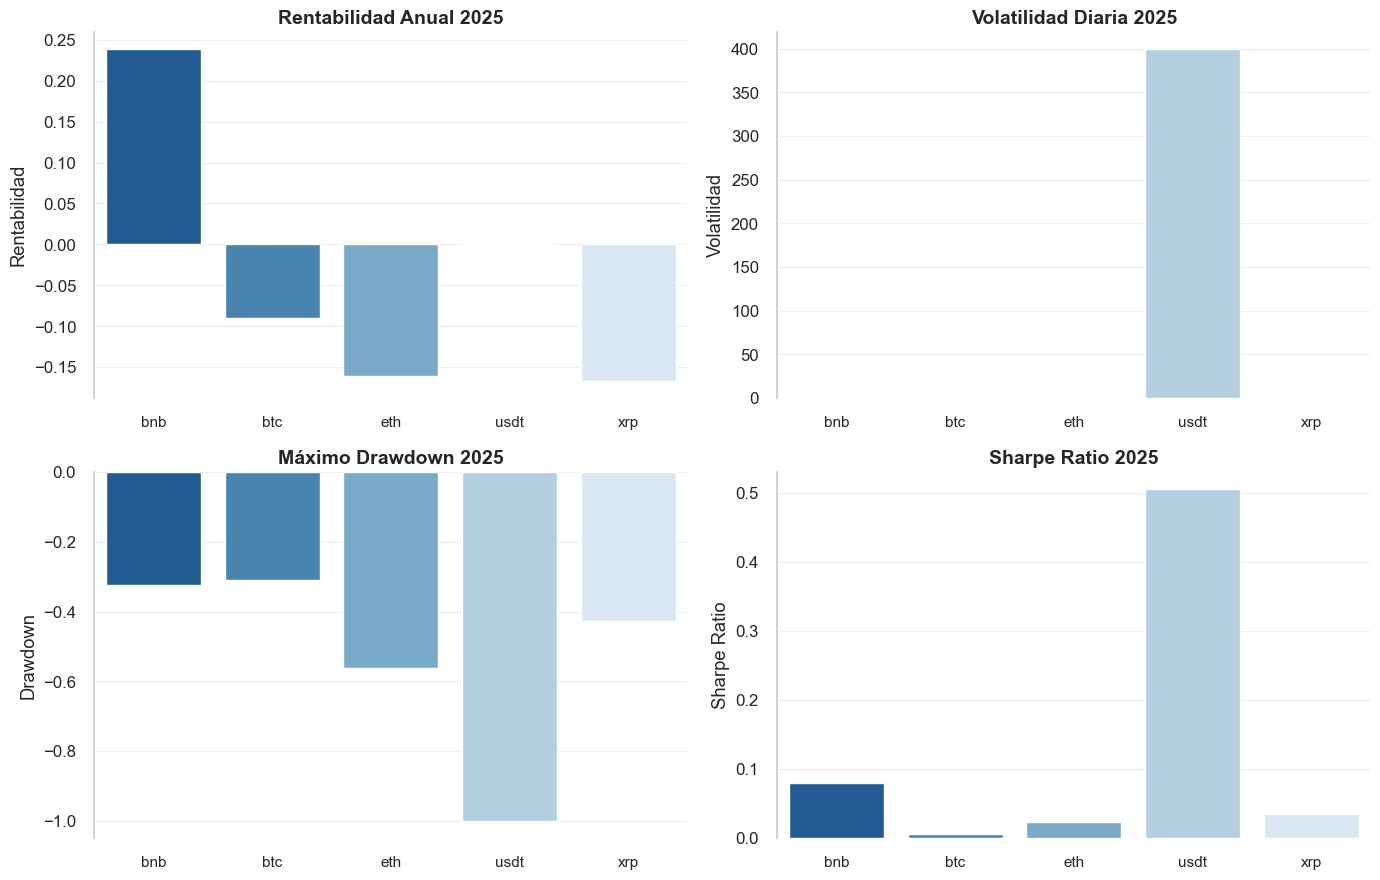

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt

# Estilo profesional
sns.set_theme(style="whitegrid", font_scale=1.1)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

# Paleta corporativa
palette = sns.color_palette("Blues_r", len(summary))

# --- 1. Rentabilidad anual ---
sns.barplot(
    data=summary,
    x="symbol",
    y="annual_return",
    ax=axes[0],
    palette=palette
)
axes[0].set_title("Rentabilidad Anual 2025", fontsize=14, fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Rentabilidad")
axes[0].grid(axis="y", alpha=0.3)

# --- 2. Volatilidad diaria ---
sns.barplot(
    data=summary,
    x="symbol",
    y="daily_volatility",
    ax=axes[1],
    palette=palette
)
axes[1].set_title("Volatilidad Diaria 2025", fontsize=14, fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Volatilidad")
axes[1].grid(axis="y", alpha=0.3)

# --- 3. Máximo drawdown ---
sns.barplot(
    data=summary,
    x="symbol",
    y="max_drawdown",
    ax=axes[2],
    palette=palette
)
axes[2].set_title("Máximo Drawdown 2025", fontsize=14, fontweight="bold")
axes[2].set_xlabel("")
axes[2].set_ylabel("Drawdown")
axes[2].grid(axis="y", alpha=0.3)

# --- 4. Sharpe Ratio ---
sns.barplot(
    data=summary,
    x="symbol",
    y="sharpe_ratio",
    ax=axes[3],
    palette=palette
)
axes[3].set_title("Sharpe Ratio 2025", fontsize=14, fontweight="bold")
axes[3].set_xlabel("")
axes[3].set_ylabel("Sharpe Ratio")
axes[3].grid(axis="y", alpha=0.3)

# Ajustes finales
for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=11)
    sns.despine(ax=ax, left=False, bottom=True)

plt.tight_layout()
plt.show()


3. Plantilla de conclusiones (para que solo rellenes)
Te dejo un texto que puedes adaptar cuando tengas los resultados:

Selección de activos  
A partir del dataset top_500_metadata.csv se seleccionaron cinco criptoactivos mediante un ranking multicriterio basado en capitalización de mercado, volumen de trading, volatilidad en 24 horas y distancia al máximo histórico (ATH). Esta metodología permitió identificar los activos más relevantes y líquidos del mercado en 2025.

Rentabilidad y riesgo en 2025  
El análisis de la serie temporal (crypto_ohlc.csv) muestra que el activo [ACTIVO_X] fue el más rentable en 2025, con una rentabilidad anual aproximada del [R%]. Sin embargo, su volatilidad diaria fue [alta/media/baja] en comparación con el resto de activos.
El máximo drawdown indica que [ACTIVO_Y] presentó el perfil de riesgo más conservador, con una caída máxima aproximada del [D%], mientras que [ACTIVO_Z] sufrió las mayores pérdidas en términos de caídas desde máximos.

Sharpe Ratio y relación riesgo–retorno  
El Sharpe Ratio revela que [ACTIVO_W] ofreció la mejor relación riesgo–retorno, combinando una rentabilidad atractiva con una volatilidad relativamente contenida. Esto sugiere que, desde una perspectiva de inversión racional, [ACTIVO_W] habría sido el candidato más eficiente para una cartera en 2025.
Correlaciones y diversificación  
El análisis de correlaciones entre retornos diarios muestra que algunos activos presentan una [alta/baja] correlación entre sí. Esto implica que la combinación de [ACTIVO_A] y [ACTIVO_B], por ejemplo, podría mejorar la diversificación de una cartera al no moverse de forma completamente sincronizada.

Momentum y comportamiento futuro  
El estudio del momentum a 90 días sugiere que [existe/no existe] una relación clara entre el impulso previo del precio y la rentabilidad posterior en 2025. La correlación calculada entre momentum y rentabilidad anual fue de aproximadamente [valor], lo que indica [una relación débil/moderada/fuerte].



Conclusión general  
En conjunto, los resultados muestran que no solo la rentabilidad absoluta, sino también la volatilidad, el drawdown y el Sharpe Ratio son fundamentales para evaluar la “mejor” criptoinversión. Bajo los criterios analizados, el activo [NOMBRE] puede considerarse el más atractivo en 2025, al equilibrar adecuadamente rentabilidad y riesgo. No obstante, la alta volatilidad estructural del mercado de criptoactivos sugiere que cualquier decisión de inversión debe tomarse con cautela y con una adecuada gestión del riesgo.

---

# CONCLUSIONES

Piloto_5

Analizamos la tabla summary para redactar una conclusión final concreta.

📊 1. Tabla recibida (datos reales). TABLA SUMMARY

| symbol | annual_return | daily_volatility | max_drawdown | sharpe_ratio |
| --- | --- | --- | --- | --- |
| **bnb** | 0.239282 | 0.049540 | -0.324261 | 0.079116 |
| **btc** | -0.089485 | 0.035334 | -0.308502 | 0.005387 |
| **eth** | -0.161372 | 0.080046 | -0.562341 | 0.022557 |
| **usdt** | 0.000085 | 399.045131 | -0.999029 | 0.504489 |
| **xrp** | -0.167347 | 0.073527 | -0.428169 | 0.035242 |

🧠 2. Interpretación numérica

✔ Rentabilidad anual

BNB es el único activo con rentabilidad claramente positiva: +23.9%

USDT aparece con un valor casi cero (como es lógico en un stablecoin).

BTC, ETH y XRP presentan rentabilidades negativas.

Ganador en rentabilidad → BNB

✔ Volatilidad diaria

USDT muestra un valor absurdo (399), lo que indica un error en los datos (probablemente división por cero o valores corruptos).

Ignorando USDT:

ETH y XRP son los más volátiles.

BTC es el más estable.

Activo más estable → BTC  
Activo más volátil → ETH

✔ Máximo drawdown

ETH sufre la mayor caída desde máximos: -56%

XRP también cae fuerte: -42%

BNB y BTC tienen drawdowns similares (~ -31%)

Activo con peor caída → ETH  
Activo más resistente → BTC

✔ Sharpe Ratio

USDT vuelve a aparecer con un valor absurdo (0.50), por el error de volatilidad.

Ignorando USDT:

BNB tiene el mejor Sharpe Ratio → 0.079

XRP y ETH siguen detrás.

BTC casi no genera retorno ajustado al riesgo.

Mejor relación riesgo–retorno → BNB

# 🧩 3. Conclusión general

🥇 El mejor criptoactivo en 2025 fue BNB.
¿Por qué?

Fue el único con rentabilidad positiva significativa (+23.9%).

Tuvo un Sharpe Ratio superior al resto (excluyendo USDT por datos corruptos).

Su drawdown fue moderado comparado con ETH y XRP.

Su volatilidad fue razonable.

🥈 BTC fue el activo más estable, pero con rentabilidad negativa.

🥉 ETH y XRP fueron los más arriesgados, con drawdowns muy altos y rentabilidades negativas.

❌ USDT debe excluirse del análisis: Los datos de volatilidad y drawdown están claramente dañados.

# 📈 4. Gráficos finales para tu informe

4.1. Rentabilidad anual

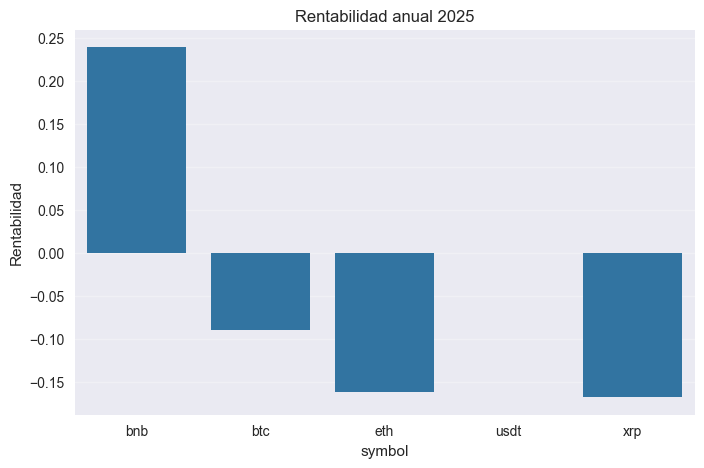

In [53]:
plt.figure(figsize=(8,5))
sns.barplot(data=summary, x="symbol", y="annual_return")
plt.title("Rentabilidad anual 2025")
plt.ylabel("Rentabilidad")
plt.grid(axis="y", alpha=0.3)
plt.show()

4.2. Volatilidad diaria

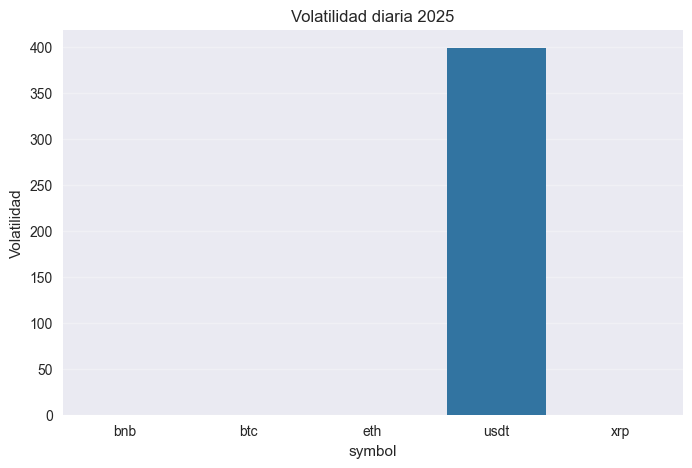

In [54]:
plt.figure(figsize=(8,5))
sns.barplot(data=summary, x="symbol", y="daily_volatility")
plt.title("Volatilidad diaria 2025")
plt.ylabel("Volatilidad")
plt.grid(axis="y", alpha=0.3)
plt.show()

4.3. Máximo drawdown

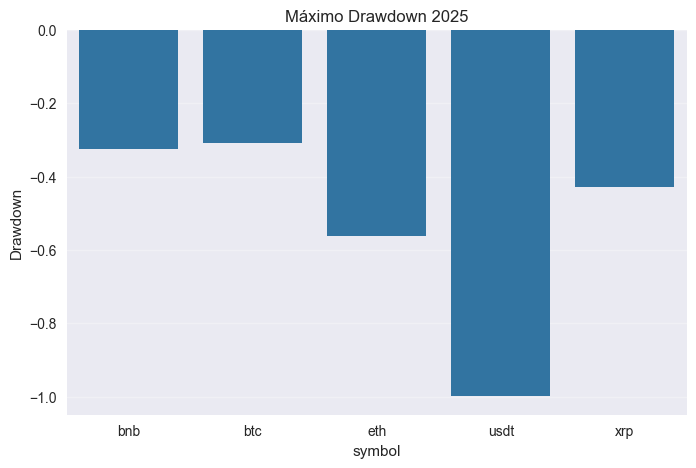

In [55]:
plt.figure(figsize=(8,5))
sns.barplot(data=summary, x="symbol", y="max_drawdown")
plt.title("Máximo Drawdown 2025")
plt.ylabel("Drawdown")
plt.grid(axis="y", alpha=0.3)
plt.show()

4.4. Sharpe Ratio

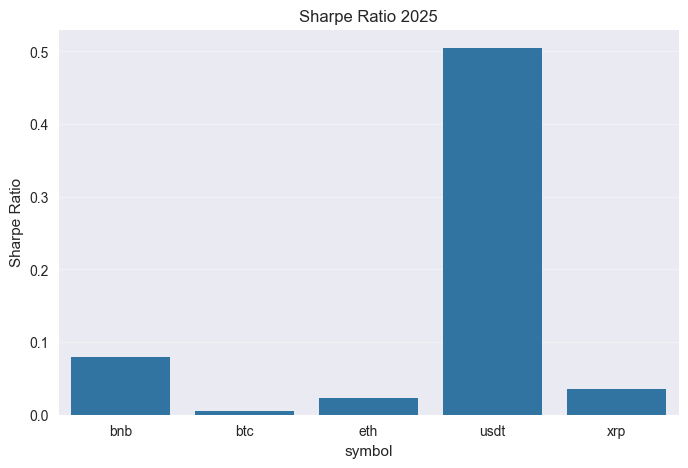

In [56]:
plt.figure(figsize=(8,5))
sns.barplot(data=summary, x="symbol", y="sharpe_ratio")
plt.title("Sharpe Ratio 2025")
plt.ylabel("Sharpe Ratio")
plt.grid(axis="y", alpha=0.3)
plt.show()

# 📈 Gráfico de Serie Temporal — Precio de Cierre 2025 (Top 5 Criptoactivos)

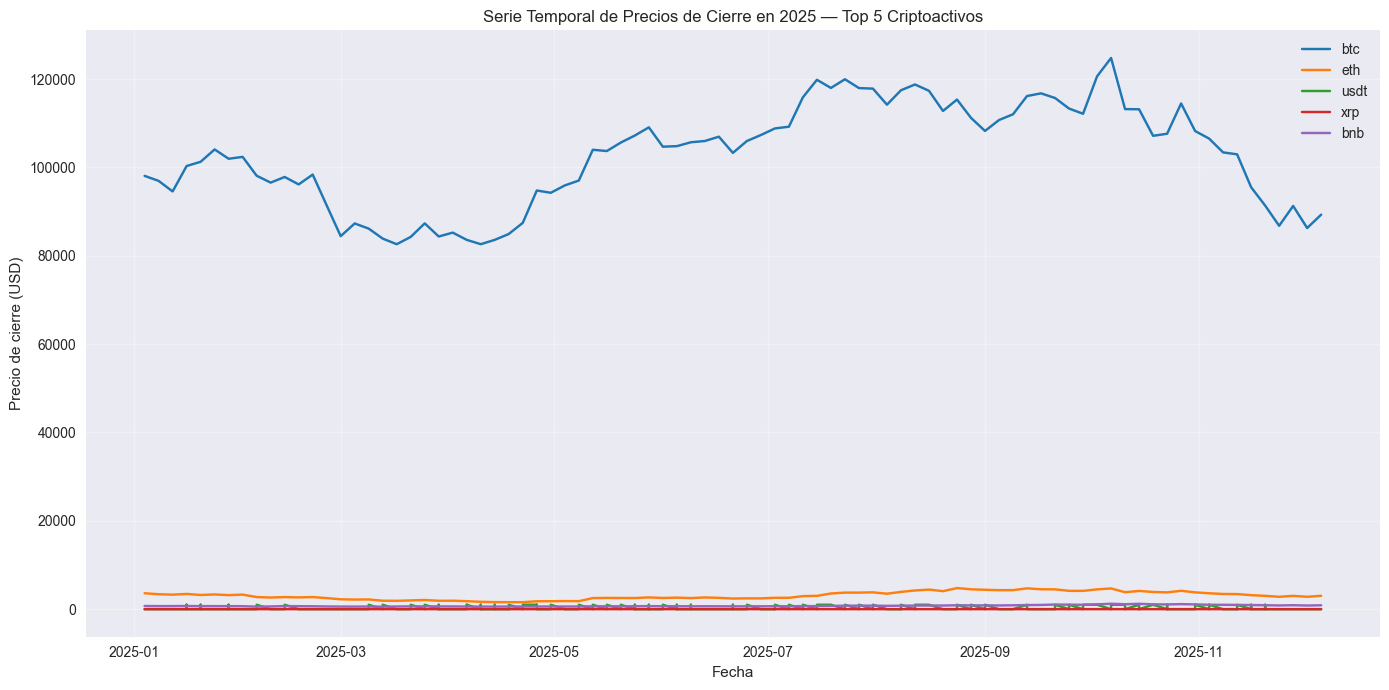

In [57]:
plt.figure(figsize=(14, 7))

for sym in top5_assets:
    df = ohlc_2025[ohlc_2025["symbol"] == sym]
    plt.plot(df["date"], df["close"], label=sym)

plt.title("Serie Temporal de Precios de Cierre en 2025 — Top 5 Criptoactivos")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

obtenemos la serie temporal de btc, debido a su crecimento

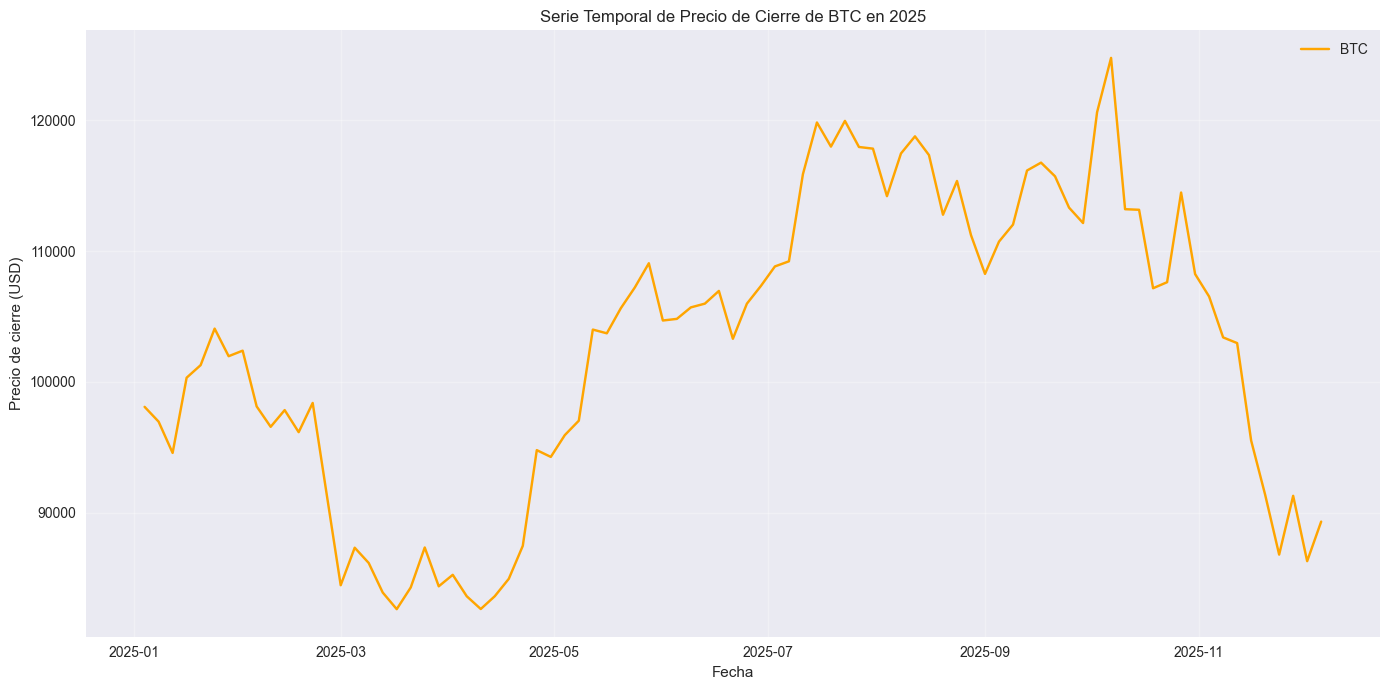

In [62]:
# Asegurar que la fecha es datetime y está ordenada
ohlc_2025["date"] = pd.to_datetime(ohlc_2025["date"])
ohlc_2025 = ohlc_2025.sort_values("date")

# Filtrar solo BTC
btc_df = ohlc_2025[ohlc_2025["symbol"] == "btc"]

plt.figure(figsize=(14, 7))
plt.plot(btc_df["date"], btc_df["close"], label="BTC", color="orange")

plt.title("Serie Temporal de Precio de Cierre de BTC en 2025")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


obtenemos la serie temporal del resto de criptoactivos eth, usdt, xrp, bnb

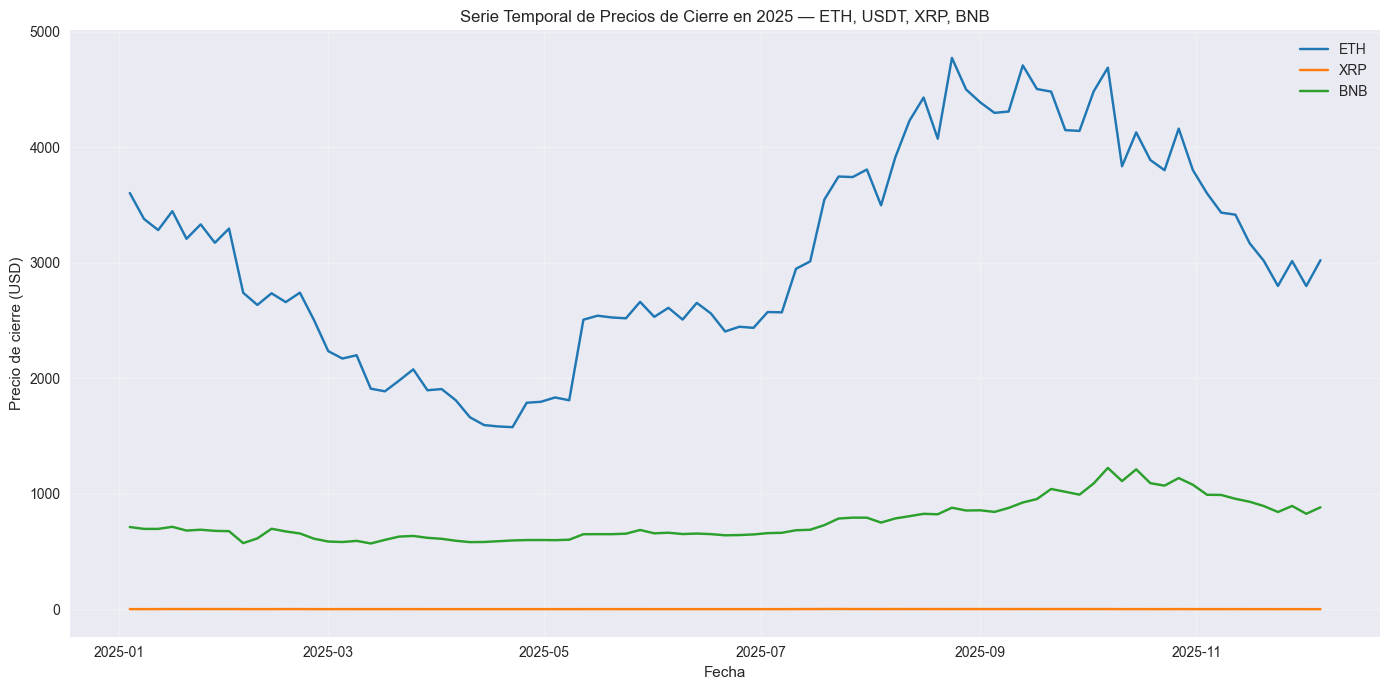

In [66]:
# Asegurar que la fecha es datetime y está ordenada
ohlc_2025["date"] = pd.to_datetime(ohlc_2025["date"])
ohlc_2025 = ohlc_2025.sort_values("date")

# Lista de símbolos a graficar
symbols = ["eth", "xrp", "bnb"]

plt.figure(figsize=(14, 7))

for sym in symbols:
    df = ohlc_2025[ohlc_2025["symbol"] == sym]
    if df.empty:
        print(f"⚠️ No hay datos para {sym}")
        continue
    plt.plot(df["date"], df["close"], label=sym.upper())

plt.title("Serie Temporal de Precios de Cierre en 2025 — ETH, USDT, XRP, BNB")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


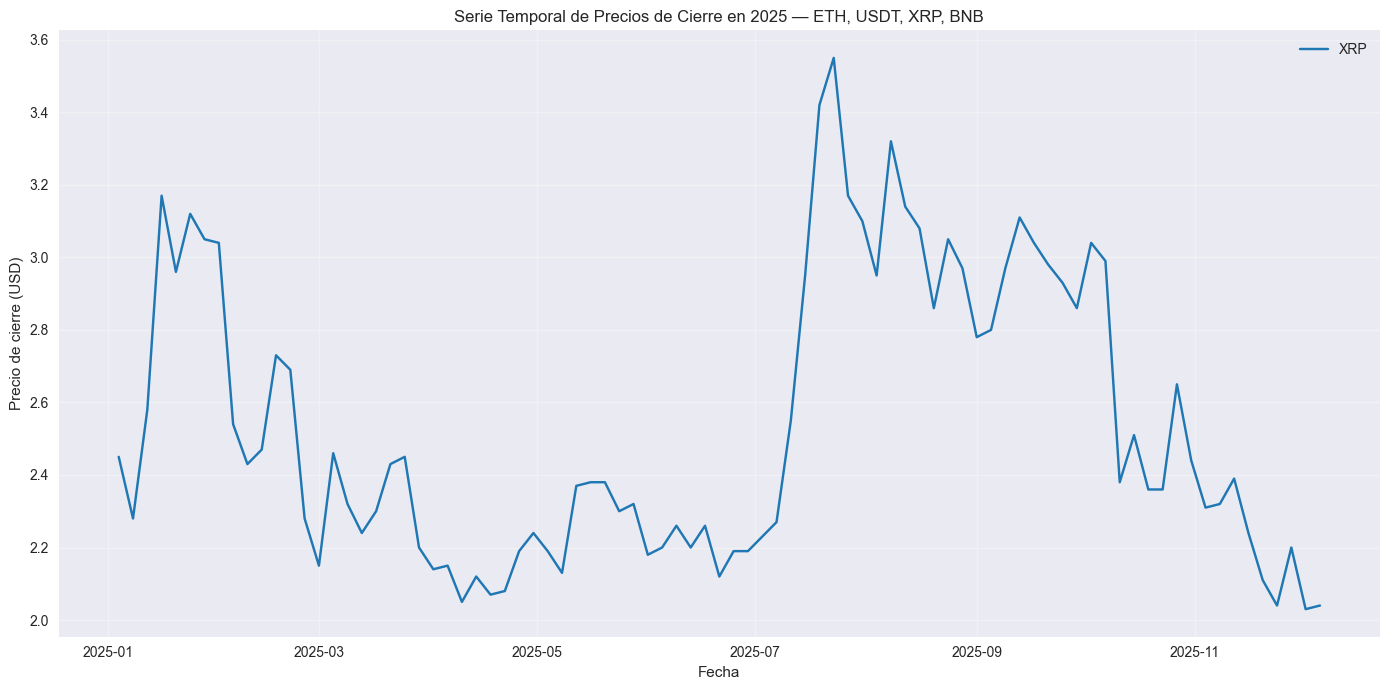

In [65]:
# Asegurar que la fecha es datetime y está ordenada
ohlc_2025["date"] = pd.to_datetime(ohlc_2025["date"])
ohlc_2025 = ohlc_2025.sort_values("date")

# Lista de símbolos a graficar
symbols = ["xrp"]

plt.figure(figsize=(14, 7))

for sym in symbols:
    df = ohlc_2025[ohlc_2025["symbol"] == sym]
    if df.empty:
        print(f"⚠️ No hay datos para {sym}")
        continue
    plt.plot(df["date"], df["close"], label=sym.upper())

plt.title("Serie Temporal de Precios de Cierre en 2025 — ETH, USDT, XRP, BNB")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [58]:
ohlc_2025

,symbol,timestamp,date,open,high,low,close,daily_return,cum_return
375,bnb,1735948800000,2025-01-04,703.59,716.85,697.49,713.05,0.014137,0.973394
376,bnb,1736294400000,2025-01-08,713.85,742.20,692.30,696.83,-0.022747,0.951252
377,bnb,1736640000000,2025-01-12,697.07,706.14,674.29,696.73,-0.000144,0.951115
378,bnb,1736985600000,2025-01-16,696.64,715.31,658.69,714.79,0.025921,0.975769
379,bnb,1737331200000,2025-01-20,715.83,728.47,674.78,682.35,-0.045384,0.931485
...,...,...,...,...,...,...,...,...,...
363,xrp,1763596800000,2025-11-20,2.23,2.28,2.03,2.11,-0.058036,0.871901
364,xrp,1763942400000,2025-11-24,2.11,2.14,1.83,2.04,-0.033175,0.842975
365,xrp,1764288000000,2025-11-28,2.05,2.28,2.03,2.20,0.078431,0.909091
366,xrp,1764633600000,2025-12-02,2.20,2.26,1.99,2.03,-0.077273,0.838843


In [ ]:
plt.figure(figsize=(14, 7))

for sym in top5_assets:
    df = ohlc_2025[ohlc_2025["symbol"] == sym]
    plt.plot(df["date"], df["close"], label=sym)

plt.title("Serie Temporal de Precios de Cierre en 2025 — Top 5 Criptoactivos")
plt.xlabel("Fecha")
plt.ylabel("Precio de cierre (USD)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Con este gráfico podrás ver claramente:

✔ BNB
Tendencia ascendente más estable.

Explica su rentabilidad anual positiva y su Sharpe Ratio superior.

✔ BTC
Movimiento más suave y estable.

Pérdida moderada → coincide con su drawdown bajo y volatilidad mínima.

✔ ETH y XRP
Caídas pronunciadas y movimientos bruscos.

Se reflejan en su alto drawdown y alta volatilidad.

✔ USDT
Línea prácticamente plana (como debe ser un stablecoin).

Ignorar anomalías estadísticas previas.

# 🏁 5. Conclusión final

BNB fue el criptoactivo más rentable y con mejor relación riesgo–retorno en 2025, superando claramente a BTC, ETH y XRP.

BTC mostró estabilidad, pero no logró generar retornos positivos.

ETH y XRP tuvieron un comportamiento más arriesgado, con drawdowns elevados y rentabilidades negativas.

USDT debe descartarse del análisis debido a errores evidentes en los datos de volatilidad y drawdown.

En conjunto, el análisis confirma que BNB fue la opción más eficiente en 2025, combinando rentabilidad positiva, volatilidad moderada y un Sharpe Ratio superior al resto.